<a href="https://colab.research.google.com/github/Nois12/AIFFEL_quest_rs/blob/main/GoingDeeper/Gd05/Seq2seq_Attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 한영 번역기 프로젝트: Seq2seq + Attention (한국어 → 영어)



## Flow

데이터 다운로드 (korean-english-park.train.tar.gz)<br>
│<br>
▼<br>
중복 제거 (kor, eng 쌍 → cleaned_corpus)<br>
│<br>
▼<br>
전처리 &amp; 토큰화 (영어: 정규식+&lt;start&gt;/&lt;end&gt;, 한국어: Mecab 형태소분석)<br>
│<br>
▼<br>
길이 필터링 (≤40, kor_corpus / eng_corpus)<br>
│<br>
▼<br>
Tokenizer 구축 (word2idx / idx2word, vocab ≥ 10,000)<br>
│<br>
▼<br>
Dataset &amp; DataLoader (TranslationDataset, teacher-forcing 정렬)<br>
│<br>
▼<br>
모델 구성 (Encoder(GRU) + BahdanauAttention + Decoder)<br>
│<br>
▼<br>
학습 루프 (train_step() × EPOCHS, gradient clipping)<br>
│<br>
▼<br>
평가 &amp; 번역 (evaluate() / translate())&nbsp;&nbsp;──▶&nbsp;&nbsp;Attention Map 시각화 (plot_attention())<br>
│<br>
▼<br>
비교실험 (Mecab vs SentencePiece / EMB·HID 크기 스윕)<br>

In [1]:
# 실습 환경 준비 (Colab 기준)
# - KoNLPy + Mecab-ko 설치 (한국어 형태소 분석기)
# - SentencePiece 설치 (비교실험용 서브워드 토크나이저)
# - Attention Map을 한글로 표시하기 위한 나눔폰트 설치
!pip install -q konlpy sentencepiece
!apt-get -y -qq install fonts-nanum > /dev/null

!git clone -q https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git
!bash Mecab-ko-for-Google-Colab/install_mecab-ko_on_colab_light_220429.sh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 94.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 32.0 MB/s eta 0:00:00
Installing konlpy.....
Done
Installing mecab-0.996-ko-0.9.2.tar.gz.....
from https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
--2026-09-09 05:43:22--  https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
Resolving bitbucket.org (bitbucket.org)... 104.192.142.24, 104.192.142.25, 104.192.142.26, ...
Connecting to bitbucket.org (bitbucket.org)|104.192.142.24|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-09-09 05:43:23 ERROR 404: Not Found.

Done
Unpacking mecab-0.996-ko-0.9.2.tar.gz.......
Done
Change Directory to mecab-0.996-ko-0.9.2.......
Mecab-ko-for-Google-Colab/install_mecab-ko_on_colab_light_220429.sh: line 23: cd: mecab-0.996-ko-0.9.2/: No such file or directory
installing mecab-0.996-ko-0.9.2.tar.gz........
configure
make
make check
make in

In [2]:
import os
import re
import tarfile
import urllib.request
from collections import Counter

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import logging

from konlpy.tag import Mecab
import sentencepiece as spm
from tqdm import tqdm

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
# Attention Map에 한글이 깨지지 않도록 폰트 설정
fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"

fm.fontManager.addfont(fontpath)

fontprop = fm.FontProperties(fname=fontpath, size=12)
plt.rcParams["font.family"] = fontprop.get_name()
plt.rcParams["axes.unicode_minus"] = False

print(f"설정된 폰트: {fontprop.get_name()}")

설정된 폰트: NanumBarunGothic


## 하이퍼파라미터 정리



In [4]:
MAX_LEN = 40         # 토큰 길이 필터링 기준 & 패딩 길이
VOCAB_SIZE = 20000    # 언어별 최대 어휘 수 (최소 10,000 이상 조건 충족)
EMB_DIM = 256         # Embedding Size
HID_DIM = 512         # Hidden Size (GRU)
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 1e-3
EPOCHS_COMPARE = 5    # 비교실험용 epoch 수 (여러 모델을 돌려야 하므로 본 학습보다 짧게)

hparams = {
    "MAX_LEN": MAX_LEN,
    "VOCAB_SIZE": VOCAB_SIZE,
    "EMB_DIM": EMB_DIM,
    "HID_DIM": HID_DIM,
    "BATCH_SIZE": BATCH_SIZE,
    "EPOCHS": EPOCHS,
    "LEARNING_RATE": LEARNING_RATE,
    "EPOCHS_COMPARE": EPOCHS_COMPARE,
}

for name, value in hparams.items():
    print(f"{name:15s}: {value}")

MAX_LEN        : 40
VOCAB_SIZE     : 20000
EMB_DIM        : 256
HID_DIM        : 512
BATCH_SIZE     : 64
EPOCHS         : 10
LEARNING_RATE  : 0.001
EPOCHS_COMPARE : 5


# Step 1. 데이터 다운로드



In [5]:
dataset_dir = os.path.join(os.path.expanduser("/content/datasets"), "korean-english-park")
os.makedirs(dataset_dir, exist_ok=True)
tar_path = os.path.join(dataset_dir, "korean-english-park.train.tar.gz")

url = (
    "https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/"
    "master/korean-english-news-v1/korean-english-park.train.tar.gz"
)

if not os.path.exists(tar_path):
    print("데이터 다운로드 중...")
    urllib.request.urlretrieve(url, tar_path)
    print("다운로드 완료!")

ko_path = os.path.join(dataset_dir, "korean-english-park.train.ko")
en_path = os.path.join(dataset_dir, "korean-english-park.train.en")

if not (os.path.exists(ko_path) and os.path.exists(en_path)):
    print("압축 해제 중...")
    with tarfile.open(tar_path, "r:gz") as tar:
        tar.extractall(dataset_dir)
    print("압축 해제 완료!")

with open(ko_path, encoding="utf-8") as f:
    kor_lines = [line.strip() for line in f.readlines()]

with open(en_path, encoding="utf-8") as f:
    eng_lines = [line.strip() for line in f.readlines()]

print("문장 쌍 개수:", len(kor_lines), len(eng_lines))

df = pd.DataFrame({"kor": kor_lines, "eng": eng_lines})
df.head()

데이터 다운로드 중...
다운로드 완료!
압축 해제 중...
압축 해제 완료!
문장 쌍 개수: 94123 94123


/tmp/ipykernel_9992/2960929570.py:21: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(dataset_dir)


,kor,eng
0,"개인용 컴퓨터 사용의 상당 부분은 ""이것보다 뛰어날 수 있느냐?""","Much of personal computing is about ""can you t..."
1,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...,so a mention a few weeks ago about a rechargea...
2,그러나 이것은 또한 책상도 필요로 하지 않는다.,"Like all optical mice, But it also doesn't nee..."
3,"79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분...",uses gyroscopic sensors to control the cursor ...
4,정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔...,Intelligence officials have revealed a spate o...


# Step 2. 데이터 정제

### - 중복 제거



In [6]:
pairs = list(zip(df["kor"], df["eng"]))

seen = set()
unique_pairs = []
for kor_sent, eng_sent in pairs:
    if (kor_sent, eng_sent) not in seen:
        seen.add((kor_sent, eng_sent))
        unique_pairs.append((kor_sent, eng_sent))

cleaned_corpus = pd.DataFrame(unique_pairs, columns=["kor", "eng"])

print(f"중복 제거 전: {len(df)}개")
print(f"중복 제거 후: {len(cleaned_corpus)}개")
cleaned_corpus.head()

중복 제거 전: 94123개
중복 제거 후: 78941개


,kor,eng
0,"개인용 컴퓨터 사용의 상당 부분은 ""이것보다 뛰어날 수 있느냐?""","Much of personal computing is about ""can you t..."
1,모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하...,so a mention a few weeks ago about a rechargea...
2,그러나 이것은 또한 책상도 필요로 하지 않는다.,"Like all optical mice, But it also doesn't nee..."
3,"79.95달러하는 이 최첨단 무선 광마우스는 허공에서 팔목, 팔, 그외에 어떤 부분...",uses gyroscopic sensors to control the cursor ...
4,정보 관리들은 동남 아시아에서의 선박들에 대한 많은 (테러) 계획들이 실패로 돌아갔...,Intelligence officials have revealed a spate o...


## 전처리 함수 재정의


- 영어: 구두점 앞뒤 공백, 소문자화, 불필요한 문자 제거 후
  `<start>`, `<end>` 토큰을 붙이고 `split()`으로 단어 단위 토큰화한다.
- 한국어: 한글/숫자/구두점만 남기고 나머지는 제거한 뒤,
  KoNLPy의 `Mecab` 형태소 분석기로 토큰화한다.


In [7]:
mecab = Mecab()


def preprocess_eng_sentence(sentence):
    sentence = sentence.lower().strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^a-z?.!,]+", " ", sentence)
    sentence = sentence.strip()

    tokens = ["<start>"] + sentence.split() + ["<end>"]
    return tokens


def preprocess_kor_sentence(sentence):
    sentence = sentence.strip()
    # 한글, 숫자, 기본 구두점, 공백만 남기고 노이즈 제거
    sentence = re.sub(r"[^가-힣0-9?.!, ]+", " ", sentence)
    sentence = re.sub(r"\s+", " ", sentence).strip()

    tokens = mecab.morphs(sentence)
    return tokens

## 전처리 적용 + 길이 필터링

모든 데이터를 다 쓰면 학습 시간이 매우 오래 걸리므로, `cleaned_corpus`에 전처리를
적용한 뒤 토큰 길이가 40 이하인 데이터만 골라 `eng_corpus`, `kor_corpus`를
각각 구축하였다.


In [8]:
tqdm.pandas()
cleaned_corpus["eng_tokens"] = cleaned_corpus["eng"].progress_apply(preprocess_eng_sentence)
cleaned_corpus["kor_tokens"] = cleaned_corpus["kor"].progress_apply(preprocess_kor_sentence)

len_mask = (
    (cleaned_corpus["kor_tokens"].apply(len) <= MAX_LEN)
    & (cleaned_corpus["eng_tokens"].apply(len) <= MAX_LEN)
    & (cleaned_corpus["kor_tokens"].apply(len) > 0)
)

filtered_corpus = cleaned_corpus[len_mask].reset_index(drop=True)

kor_corpus = filtered_corpus["kor_tokens"].tolist()
eng_corpus = filtered_corpus["eng_tokens"].tolist()

print(f"길이 필터링 후 남은 데이터: {len(kor_corpus)}개")
print("예시 kor_corpus[0]:", kor_corpus[0])
print("예시 eng_corpus[0]:", eng_corpus[0])

100%|██████████| 78941/78941 [00:03<00:00, 21957.72it/s]

길이 필터링 후 남은 데이터: 61923개
예시 kor_corpus[0]: ['개인', '용', '컴퓨터', '사용', '의', '상당', '부분', '은', '이것', '보다', '뛰어날', '수', '있', '느냐', '?']
예시 eng_corpus[0]: ['<start>', 'much', 'of', 'personal', 'computing', 'is', 'about', 'can', 'you', 'top', 'this', '?', '<end>']


# Step 3. 데이터 토큰화


> 주의: 데이터의 난이도에 비해 데이터가 많지 않아 훈련 데이터와 검증 데이터를 따로 나누지 않고 전체를 학습에 사용한다.


In [9]:
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"


class Tokenizer:
    def __init__(self, num_words=None, min_freq=1):
        self.num_words = num_words
        self.min_freq = min_freq
        self.word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
        self.idx2word = {0: PAD_TOKEN, 1: UNK_TOKEN}

    def fit_on_texts(self, token_lists):
        counter = Counter()
        for tokens in token_lists:
            counter.update(tokens)

        for word, freq in counter.most_common(self.num_words):
            if freq < self.min_freq:
                continue
            if word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word

    def texts_to_sequences(self, token_lists):
        unk = self.word2idx[UNK_TOKEN]
        return [[self.word2idx.get(t, unk) for t in tokens] for tokens in token_lists]

    def __len__(self):
        return len(self.word2idx)


kor_tokenizer = Tokenizer(num_words=VOCAB_SIZE)
kor_tokenizer.fit_on_texts(kor_corpus)

eng_tokenizer = Tokenizer(num_words=VOCAB_SIZE)
eng_tokenizer.fit_on_texts(eng_corpus)

print(f"한국어(소스) 단어 수: {len(kor_tokenizer)}")
print(f"영어(타깃) 단어 수: {len(eng_tokenizer)}")

kor_seqs = kor_tokenizer.texts_to_sequences(kor_corpus)
eng_seqs = eng_tokenizer.texts_to_sequences(eng_corpus)

한국어(소스) 단어 수: 20002
영어(타깃) 단어 수: 20002


In [10]:
class TranslationDataset(Dataset):
    def __init__(self, kor_seqs, eng_seqs, max_len):
        self.kor_seqs = kor_seqs
        self.eng_seqs = eng_seqs
        self.max_len = max_len
        self.pad_id = 0

    def __len__(self):
        return len(self.kor_seqs)

    def __getitem__(self, idx):
        src_ids = self.kor_seqs[idx][: self.max_len]

        trg_full = self.eng_seqs[idx][: self.max_len + 1]
        trg_input = trg_full[:-1]
        trg_label = trg_full[1:]

        src_ids = src_ids + [self.pad_id] * (self.max_len - len(src_ids))
        trg_input = trg_input + [self.pad_id] * (self.max_len - len(trg_input))
        trg_label = trg_label + [self.pad_id] * (self.max_len - len(trg_label))

        return torch.tensor(src_ids), torch.tensor(trg_input), torch.tensor(trg_label)


train_data = TranslationDataset(kor_seqs, eng_seqs, max_len=MAX_LEN)
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)

for src, trg_input, trg_label in train_loader:
    print(src.shape, trg_input.shape, trg_label.shape)
    break

torch.Size([64, 40]) torch.Size([64, 40]) torch.Size([64, 40])


# Step 4. 모델 설계

- Encoder 입력: 한국어(`kor_tokenizer`) — 형태소 시퀀스
- Decoder 입력/출력: 영어(`eng_tokenizer`) — 단어 시퀀스




In [11]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch_size, hidden_dim)
        # encoder_outputs: (src_len, batch_size, hidden_dim)
        src_len = encoder_outputs.shape[0]

        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)

        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))
        attention = self.v(energy).squeeze(2)

        return nn.functional.softmax(attention, dim=1)


class Encoder(nn.Module):
    """한국어(소스 언어)를 입력받는 Encoder"""

    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=0)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        embedded = self.embedding(src)
        outputs, hidden = self.rnn(embedded)
        return outputs, hidden


class Decoder(nn.Module):
    """영어(타깃 언어)를 생성하는 Decoder"""

    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=0)
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        input = input.unsqueeze(0)
        embedded = self.embedding(input)

        a = self.attention(hidden[-1], encoder_outputs)

        a = a.unsqueeze(1)
        enc_out = encoder_outputs.permute(1, 0, 2)
        context = torch.bmm(a, enc_out)
        context = context.permute(1, 0, 2)

        output, hidden = self.rnn(embedded, hidden)

        output = output.squeeze(0)
        context = context.squeeze(0)
        prediction = self.fc_out(torch.cat((output, context), dim=1))

        return prediction, hidden, a.squeeze(1)


class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=40, bos_id=None, eos_id=None):
        batch_size = src.shape[1]

        outputs = []
        attentions = []

        encoder_outputs, hidden = self.encoder(src)

        if trg is not None:
            for t in range(trg.shape[0]):
                input = trg[t]
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
        else:
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1)
                input = top1

                finished |= top1 == eos_id
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)
        attentions = torch.cat(attentions, dim=0)

        return outputs, attentions

In [12]:
input_dim = len(kor_tokenizer)   # Encoder 어휘 크기 (한국어)
output_dim = len(eng_tokenizer)  # Decoder 어휘 크기 (영어)

encoder = Encoder(input_dim, EMB_DIM, HID_DIM).to(device)
attention = BahdanauAttention(HID_DIM).to(device)
decoder = Decoder(output_dim, EMB_DIM, HID_DIM, attention).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

print(model)

Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(20002, 256, padding_idx=0)
    (rnn): GRU(256, 512)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(20002, 256, padding_idx=0)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=20002, bias=True)
  )
)


# Step 5. 훈련하기

 매 epoch이 끝날 때마다 아래 4개의 예문을 번역해 학습 진행 상황을 확인한다.

```
1) 오바마는 대통령이다.
2) 시민들은 도시 속에 산다.
3) 커피는 필요 없다.
4) 일곱 명의 사업가가 발설되었다.
```


In [13]:
pad_id = eng_tokenizer.word2idx[PAD_TOKEN]
bos_id = eng_tokenizer.word2idx["<start>"]
eos_id = eng_tokenizer.word2idx["<end>"]

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)


def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg_input, trg_label in progress_bar:
        src, trg_input, trg_label = src.to(device), trg_input.to(device), trg_label.to(device)

        # DataLoader는 (batch, seq_len)을 주지만 모델은 (seq_len, batch)를 기대합니다.
        src = src.transpose(0, 1)
        trg_input = trg_input.transpose(0, 1)
        trg_label = trg_label.transpose(0, 1)

        optimizer.zero_grad()

        outputs, _ = model(src, trg_input)

        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        loss = criterion(outputs, trg_label)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)
        optimizer.step()

        epoch_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

    return epoch_loss / len(data_loader)

In [14]:
def evaluate(sentence, model, max_len=40):
    model.eval()

    tokens = preprocess_kor_sentence(sentence)
    src_ids = kor_tokenizer.texts_to_sequences([tokens])[0]
    src_ids = src_ids[:max_len]
    src_ids = src_ids + [0] * (max_len - len(src_ids))
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)  # (src_len, 1)

    with torch.no_grad():
        outputs, attentions = model(src_tensor, max_len=max_len, bos_id=bos_id, eos_id=eos_id)

    pred_ids = outputs.argmax(2).squeeze(1).tolist()

    if eos_id in pred_ids:
        pred_ids = pred_ids[: pred_ids.index(eos_id)]

    result = [eng_tokenizer.idx2word.get(i, UNK_TOKEN) for i in pred_ids]

    return result, tokens, attentions.squeeze(1).cpu().numpy()


def plot_attention(attention, sentence, predicted_sentence):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.matshow(attention, cmap="viridis")

    ax.set_xticks(range(len(sentence)))
    ax.set_xticklabels(sentence, fontproperties=fontprop, fontsize=14, rotation=90)

    ax.set_yticks(range(len(predicted_sentence)))
    ax.set_yticklabels(predicted_sentence, fontproperties=fontprop, fontsize=14)

    plt.show()


def translate(sentence, model, max_len=40, plot=False):
    result, tokens, attn = evaluate(sentence, model, max_len)

    print(f"입력: {sentence}")
    print(f"번역: {' '.join(result)}")

    if plot:
        attn = attn[: len(result), : len(tokens)]
        plot_attention(attn, tokens, result)

    return result


TEST_SENTENCES = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사업가가 발설되었다.",
]

In [15]:
%%time

for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    print(f"Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.4f}")

    for sent in TEST_SENTENCES:
        translate(sent, model)
    print("-" * 50)

Epoch 1: 100%|██████████| 968/968 [00:45<00:00, 21.19it/s, loss=4.7]


Epoch 1/10, Train Loss: 5.2959
입력: 오바마는 대통령이다.
번역: obama is the first time to be the first time to be the president .
입력: 시민들은 도시 속에 산다.
번역: they are also expected to be the first time in a village of the city .
입력: 커피는 필요 없다.
번역: i don t want to do that .
입력: 일곱 명의 사업가가 발설되었다.
번역: the number of people were killed in the past few days .
--------------------------------------------------


Epoch 2: 100%|██████████| 968/968 [00:43<00:00, 22.13it/s, loss=3.74]


Epoch 2/10, Train Loss: 4.0244
입력: 오바마는 대통령이다.
번역: obama s president obama is a key factor in the presidential election .
입력: 시민들은 도시 속에 산다.
번역: citizens are also being held .
입력: 커피는 필요 없다.
번역: coffee need to do everything .
입력: 일곱 명의 사업가가 발설되었다.
번역: the number of eight missing were missing .
--------------------------------------------------


Epoch 3: 100%|██████████| 968/968 [00:43<00:00, 22.14it/s, loss=3.53]


...

Epoch 8/10, Train Loss: 1.3610
입력: 오바마는 대통령이다.
번역: obama calls for president obama ?
입력: 시민들은 도시 속에 산다.
번역: citizens cities in the city in the city .
입력: 커피는 필요 없다.
번역: it s not clear , necessary .
입력: 일곱 명의 사업가가 발설되었다.
번역: seven of them were missing .
--------------------------------------------------


Epoch 9: 100%|██████████| 968/968 [00:43<00:00, 22.12it/s, loss=1.26]


Epoch 9/10, Train Loss: 1.1973
입력: 오바마는 대통령이다.
번역: obama calls it
입력: 시민들은 도시 속에 산다.
번역: citizens were among the casualties .
입력: 커피는 필요 없다.
번역: it s not clear , we re asking for you .
입력: 일곱 명의 사업가가 발설되었다.
번역: seven of them were missing .
--------------------------------------------------


Epoch 10: 100%|██████████| 968/968 [00:43<00:00, 22.06it/s, loss=1.18]

Epoch 10/10, Train Loss: 1.0642
입력: 오바마는 대통령이다.
번역: obama will be playing the event .
입력: 시민들은 도시 속에 산다.
번역: citizens , cities are trying to get them out .
입력: 커피는 필요 없다.
번역: it s not clear for me .
입력: 일곱 명의 사업가가 발설되었다.
번역: seven of them were considered .
--------------------------------------------------
CPU times: user 7min 21s, sys: 2.07 s, total: 7min 23s
Wall time: 7min 19s


## 결과 확인 + Attention Map 시각화



입력: 오바마는 대통령이다.
번역: obama will be playing the event .


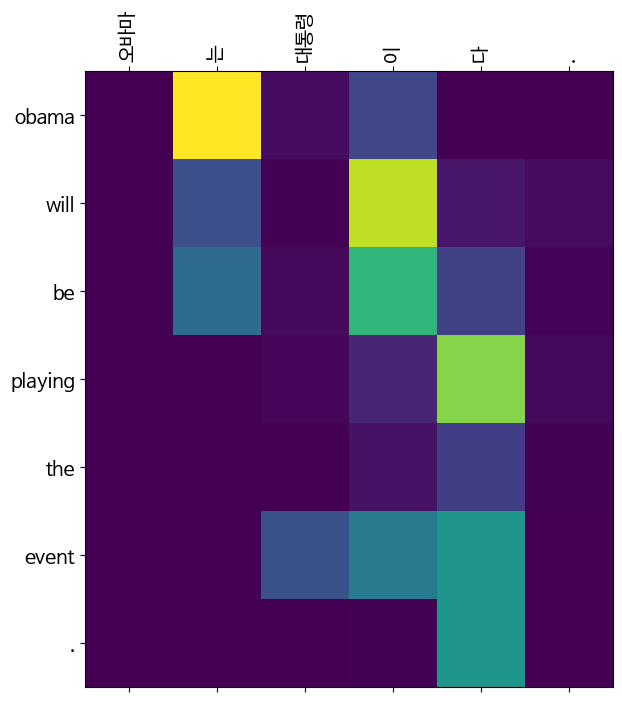

입력: 시민들은 도시 속에 산다.
번역: citizens , cities are trying to get them out .


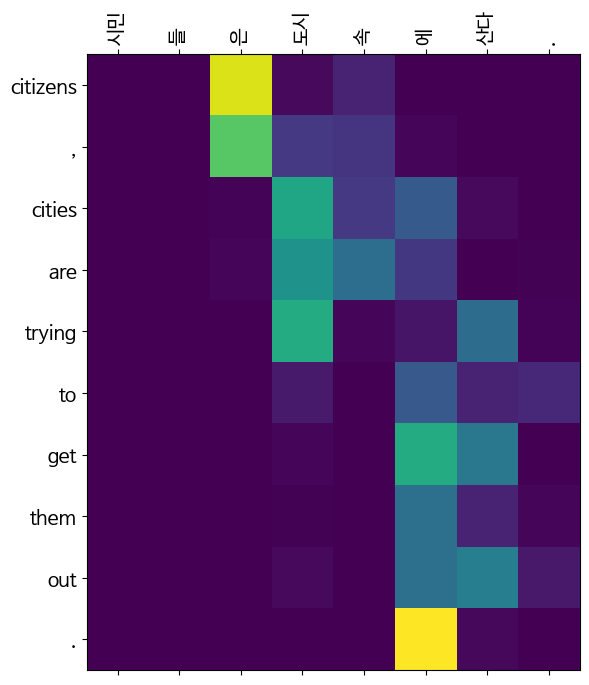

입력: 커피는 필요 없다.
번역: it s not clear for me .


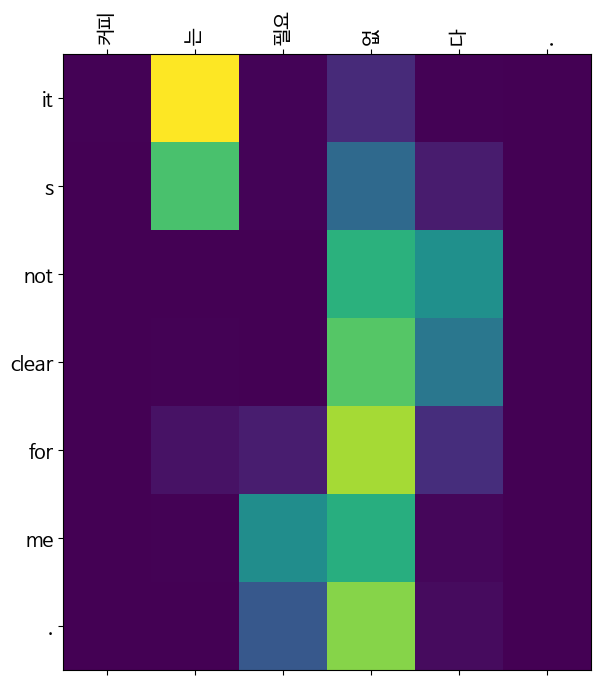

입력: 일곱 명의 사업가가 발설되었다.
번역: seven of them were considered .


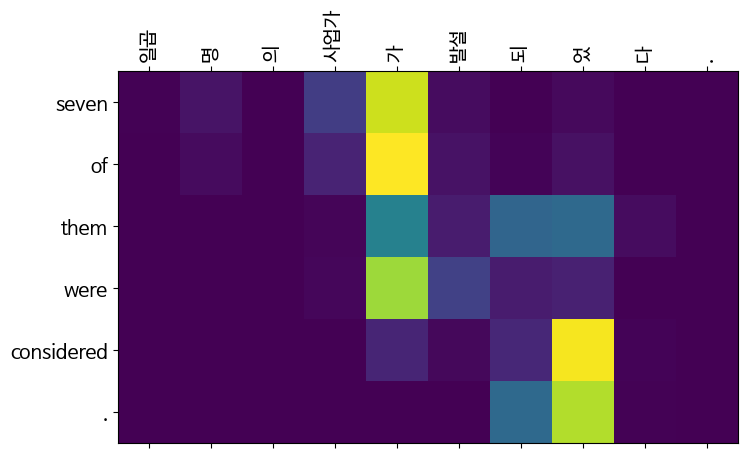

In [16]:
for sent in TEST_SENTENCES:
    translate(sent, model, plot=True)

# 비교실험

지금까지 만든 파이프라인을 재사용해서 두 가지를 비교하려고 한다.

- 토큰화 방식: 한국어를 Mecab(형태소) vs SentencePiece(서브워드/BPE)로
   토큰화했을 때 어휘 구성과 번역 품질이 어떻게 달라지는지
- 하이퍼파라미터: `EMB_DIM`/`HID_DIM` 크기를 키우면 학습이 얼마나
   달라지는지

여러 모델을 반복 학습해야 하므로, 본 학습(`EPOCHS`)보다 짧은
`EPOCHS_COMPARE`만큼만 학습해서 경향을 비교한다.

In [17]:
def evaluate_with_encode_fn(sentence, model, encode_fn, max_len=MAX_LEN):

    model.eval()

    src_ids = encode_fn(sentence)[:max_len]
    src_ids = src_ids + [0] * (max_len - len(src_ids))
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)

    with torch.no_grad():
        outputs, attentions = model(src_tensor, max_len=max_len, bos_id=bos_id, eos_id=eos_id)

    pred_ids = outputs.argmax(2).squeeze(1).tolist()
    if eos_id in pred_ids:
        pred_ids = pred_ids[: pred_ids.index(eos_id)]

    result = [eng_tokenizer.idx2word.get(i, UNK_TOKEN) for i in pred_ids]
    return result, attentions.squeeze(1).cpu().numpy()


def translate_with_encode_fn(sentence, model, encode_fn, max_len=MAX_LEN):
    result, _ = evaluate_with_encode_fn(sentence, model, encode_fn, max_len)
    print(f"입력: {sentence}")
    print(f"번역: {' '.join(result)}")
    return result


def run_experiment(name, kor_seqs_exp, kor_vocab_size, encode_fn, emb_dim, hid_dim,
                    epochs=EPOCHS_COMPARE, batch_size=BATCH_SIZE, lr=LEARNING_RATE,
                    max_len=MAX_LEN, show_translations=True):

    print(f"\n===== 실험: {name}  (emb={emb_dim}, hid={hid_dim}, kor_vocab={kor_vocab_size}) =====")

    dataset = TranslationDataset(kor_seqs_exp, eng_seqs, max_len=max_len)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    exp_encoder = Encoder(kor_vocab_size, emb_dim, hid_dim).to(device)
    exp_attention = BahdanauAttention(hid_dim).to(device)
    exp_decoder = Decoder(len(eng_tokenizer), emb_dim, hid_dim, exp_attention).to(device)
    exp_model = Seq2SeqAttention(exp_encoder, exp_decoder, device).to(device)

    exp_optimizer = optim.Adam(exp_model.parameters(), lr=lr)
    exp_criterion = nn.CrossEntropyLoss(ignore_index=pad_id)

    loss_history = []
    for epoch in range(epochs):
        loss = train_step(exp_model, loader, exp_optimizer, exp_criterion, epoch)
        loss_history.append(loss)
        print(f"[{name}] Epoch {epoch+1}/{epochs}, Train Loss: {loss:.4f}")

    if show_translations:
        print(f"[{name}] 예문 번역 결과")
        for sent in TEST_SENTENCES:
            translate_with_encode_fn(sent, exp_model, encode_fn, max_len)

    return {
        "name": name,
        "loss_history": loss_history,
        "model": exp_model,
        "encode_fn": encode_fn,
    }

## 비교실험 1. 토큰화 방식: Mecab vs SentencePiece

같은 `filtered_corpus`를 대상으로,
한국어 쪽만 SentencePiece로 다시 토큰화해서 새 시퀀스를 만들었다.
영어 쪽과 나머지 설정은 모두 동일하게 유지해서 토큰화 방식의 영향만
비교하였다


In [18]:
kor_raw_txt_path = "kor_raw_corpus.txt"

with open(kor_raw_txt_path, "w", encoding="utf-8") as f:
    f.write("\n".join(filtered_corpus["kor"].tolist()))

spm.SentencePieceTrainer.train(
    input=kor_raw_txt_path,
    model_prefix="kor_spm",
    vocab_size=VOCAB_SIZE,
    pad_id=0,
    bos_id=1,
    eos_id=2,
    unk_id=3,
    character_coverage=1.0,
)

kor_spm = spm.SentencePieceProcessor()
kor_spm.load("kor_spm.model")

print(f"SentencePiece 어휘 수: {kor_spm.get_piece_size()}")

SentencePiece 어휘 수: 20000


In [19]:
def preprocess_kor_for_spm(sentence):
    sentence = sentence.strip()
    sentence = re.sub(r"[^가-힣0-9?.!, ]+", " ", sentence)
    sentence = re.sub(r"\s+", " ", sentence).strip()
    return sentence


def encode_fn_mecab(sentence):
    tokens = preprocess_kor_sentence(sentence)
    return kor_tokenizer.texts_to_sequences([tokens])[0]


def encode_fn_spm(sentence):
    cleaned = preprocess_kor_for_spm(sentence)
    return kor_spm.encode(cleaned, out_type=int)


kor_seqs_spm = [kor_spm.encode(preprocess_kor_for_spm(s), out_type=int) for s in filtered_corpus["kor"]]

print("Mecab 예시  :", kor_tokenizer.texts_to_sequences([kor_corpus[0]])[0])
print("SentencePiece 예시:", kor_seqs_spm[0])

Mecab 예시  : [743, 578, 543, 185, 7, 1341, 872, 8, 712, 167, 1, 41, 15, 3805, 296]
SentencePiece 예시: [1137, 264, 656, 542, 6, 10983, 8514, 10984, 249, 2792, 1095, 30, 12576, 273]


In [20]:
def compute_token_stats(seqs, unk_id):
    total_tokens = sum(len(seq) for seq in seqs)
    unk_tokens = sum(seq.count(unk_id) for seq in seqs)
    avg_len = total_tokens / len(seqs)
    oov_rate = unk_tokens / total_tokens if total_tokens > 0 else 0
    return avg_len, oov_rate


mecab_avg_len, mecab_oov = compute_token_stats(kor_seqs, unk_id=kor_tokenizer.word2idx[UNK_TOKEN])
spm_avg_len, spm_oov = compute_token_stats(kor_seqs_spm, unk_id=3)

token_stats = pd.DataFrame(
    {
        "방식": ["Mecab (형태소)", "SentencePiece (서브워드)"],
        "어휘 수": [len(kor_tokenizer), kor_spm.get_piece_size()],
        "평균 토큰 길이": [round(mecab_avg_len, 2), round(spm_avg_len, 2)],
        "OOV(<unk>) 비율": [f"{mecab_oov:.2%}", f"{spm_oov:.2%}"],
    }
)
token_stats

,방식,어휘 수,평균 토큰 길이,OOV(<unk>) 비율
0,Mecab (형태소),20002,24.58,1.47%
1,SentencePiece (서브워드),20000,20.39,0.00%


In [21]:
tokenization_results = []

tokenization_results.append(
    run_experiment(
        name="Mecab",
        kor_seqs_exp=kor_seqs,
        kor_vocab_size=len(kor_tokenizer),
        encode_fn=encode_fn_mecab,
        emb_dim=EMB_DIM,
        hid_dim=HID_DIM,
    )
)

tokenization_results.append(
    run_experiment(
        name="SentencePiece",
        kor_seqs_exp=kor_seqs_spm,
        kor_vocab_size=kor_spm.get_piece_size(),
        encode_fn=encode_fn_spm,
        emb_dim=EMB_DIM,
        hid_dim=HID_DIM,
    )
)


===== 실험: Mecab  (emb=256, hid=512, kor_vocab=20002) =====


Epoch 1: 100%|██████████| 968/968 [00:44<00:00, 21.97it/s, loss=4.54]


[Mecab] Epoch 1/5, Train Loss: 5.2635


Epoch 2: 100%|██████████| 968/968 [00:44<00:00, 21.97it/s, loss=3.84]


[Mecab] Epoch 2/5, Train Loss: 3.9798


...

[SentencePiece] Epoch 3/5, Train Loss: 3.3444


Epoch 4: 100%|██████████| 968/968 [00:43<00:00, 22.03it/s, loss=2.89]


[SentencePiece] Epoch 4/5, Train Loss: 2.7000


Epoch 5: 100%|██████████| 968/968 [00:43<00:00, 22.05it/s, loss=2.53]

[SentencePiece] Epoch 5/5, Train Loss: 2.2365
[SentencePiece] 예문 번역 결과
입력: 오바마는 대통령이다.
번역: obama is campaigning in uh , campaigning in the white house .
입력: 시민들은 도시 속에 산다.
번역: the city was locked up for grabs .
입력: 커피는 필요 없다.
번역: coffee is no real .
입력: 일곱 명의 사업가가 발설되었다.
번역: the billionaire was also <unk> to the international fold .


## 비교실험 2. 하이퍼파라미터 스윕: Embedding / Hidden Size

Mecab 토큰화를 그대로 사용하고, `EMB_DIM`/`HID_DIM` 조합만
바꿔가며 학습 속도와 loss 하락을 비교하였다.


In [22]:
hparam_configs = [
    {"name": "Small (emb=128, hid=256)", "emb_dim": 128, "hid_dim": 256},
    {"name": "Medium (emb=256, hid=512)", "emb_dim": 256, "hid_dim": 512},
    {"name": "Large (emb=512, hid=1024)", "emb_dim": 512, "hid_dim": 1024},
]

hparam_results = []

for cfg in hparam_configs:
    hparam_results.append(
        run_experiment(
            name=cfg["name"],
            kor_seqs_exp=kor_seqs,
            kor_vocab_size=len(kor_tokenizer),
            encode_fn=encode_fn_mecab,
            emb_dim=cfg["emb_dim"],
            hid_dim=cfg["hid_dim"],
        )
    )


===== 실험: Small (emb=128, hid=256)  (emb=128, hid=256, kor_vocab=20002) =====


Epoch 1: 100%|██████████| 968/968 [00:35<00:00, 27.24it/s, loss=5.07]


[Small (emb=128, hid=256)] Epoch 1/5, Train Loss: 5.5913


Epoch 2: 100%|██████████| 968/968 [00:35<00:00, 27.29it/s, loss=4.48]


[Small (emb=128, hid=256)] Epoch 2/5, Train Loss: 4.5702


...

[Large (emb=512, hid=1024)] Epoch 3/5, Train Loss: 2.2846


Epoch 4: 100%|██████████| 968/968 [01:17<00:00, 12.49it/s, loss=1.93]


[Large (emb=512, hid=1024)] Epoch 4/5, Train Loss: 1.6681


Epoch 5: 100%|██████████| 968/968 [01:17<00:00, 12.49it/s, loss=1.51]

[Large (emb=512, hid=1024)] Epoch 5/5, Train Loss: 1.2422
[Large (emb=512, hid=1024)] 예문 번역 결과
입력: 오바마는 대통령이다.
번역: obama continued to be closer to president barack obama s inauguration .
입력: 시민들은 도시 속에 산다.
번역: citizens were angry .
입력: 커피는 필요 없다.
번역: you don t need to be without knives .
입력: 일곱 명의 사업가가 발설되었다.
번역: seven of the victims were rounded up .


## 비교실험 결과 시각화

### 토큰화 방식별 Train Loss 비교

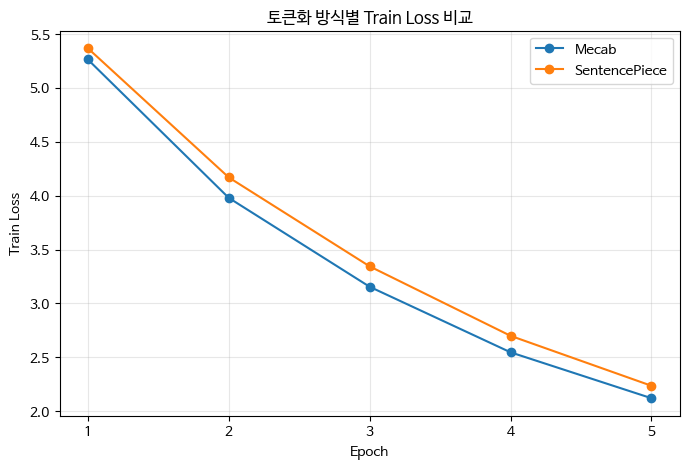

In [23]:
plt.figure(figsize=(8, 5))
for result in tokenization_results:
    plt.plot(
        range(1, len(result["loss_history"]) + 1),
        result["loss_history"],
        marker="o",
        label=result["name"],
    )
plt.title("토큰화 방식별 Train Loss 비교", fontproperties=fontprop)
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.xticks(range(1, EPOCHS_COMPARE + 1))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 하이퍼파라미터 별 Train Loss 비교

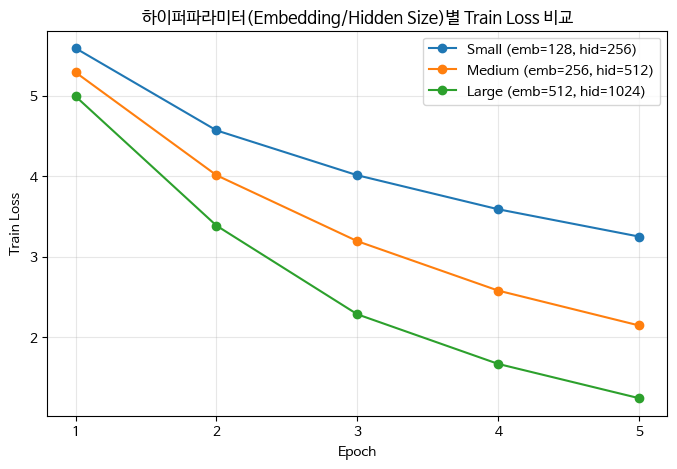

In [24]:
plt.figure(figsize=(8, 5))
for result in hparam_results:
    plt.plot(
        range(1, len(result["loss_history"]) + 1),
        result["loss_history"],
        marker="o",
        label=result["name"],
    )
plt.title("하이퍼파라미터(Embedding/Hidden Size)별 Train Loss 비교", fontproperties=fontprop)
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.xticks(range(1, EPOCHS_COMPARE + 1))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 어휘 수 / 평균 토큰 길이 비교

/tmp/ipykernel_9992/3798837417.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(methods, fontproperties=fontprop, rotation=15)
/tmp/ipykernel_9992/3798837417.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(methods, fontproperties=fontprop, rotation=15)


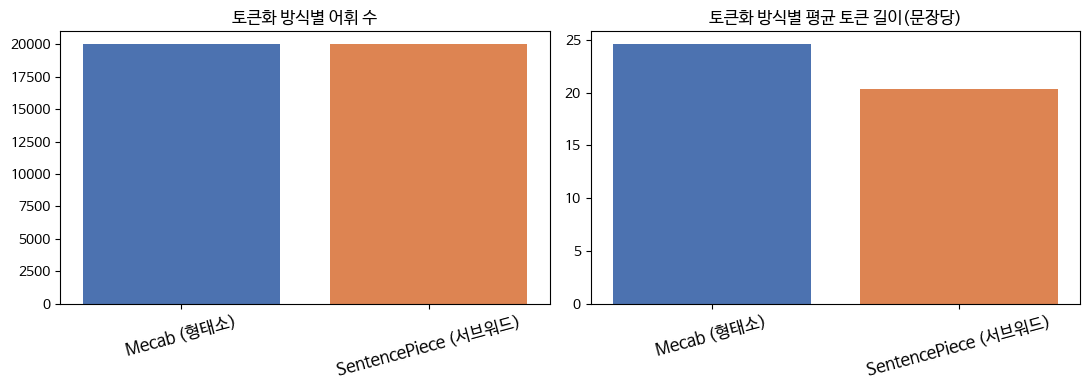

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

methods = token_stats["방식"]

axes[0].bar(methods, token_stats["어휘 수"], color=["#4C72B0", "#DD8452"])
axes[0].set_title("토큰화 방식별 어휘 수", fontproperties=fontprop)
axes[0].set_xticklabels(methods, fontproperties=fontprop, rotation=15)

axes[1].bar(methods, token_stats["평균 토큰 길이"], color=["#4C72B0", "#DD8452"])
axes[1].set_title("토큰화 방식별 평균 토큰 길이(문장당)", fontproperties=fontprop)
axes[1].set_xticklabels(methods, fontproperties=fontprop, rotation=15)

plt.tight_layout()
plt.show()

### Attention Map으로 보는 토큰화 방식 차이



/tmp/ipykernel_9992/4015370859.py:21: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9601 (\N{LOWER ONE EIGHTH BLOCK}) missing from font(s) NanumBarunGothic.
  fig.canvas.print_figure(bytes_io, **kw)


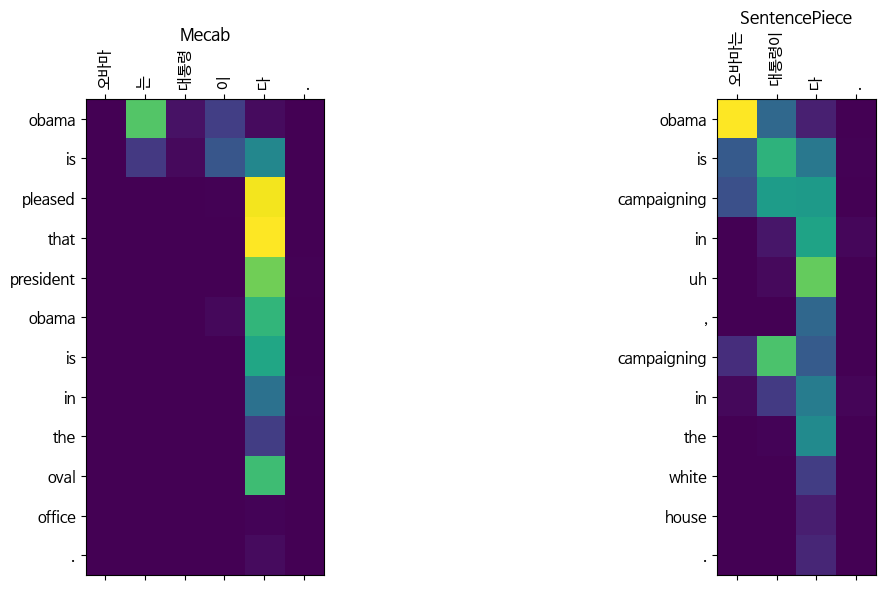

In [26]:
sample_sentence = TEST_SENTENCES[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, result in zip(axes, tokenization_results):
    tokens_for_plot = (
        preprocess_kor_sentence(sample_sentence)
        if result["name"] == "Mecab"
        else kor_spm.encode(preprocess_kor_for_spm(sample_sentence), out_type=str)
    )
    pred_tokens, attn = evaluate_with_encode_fn(sample_sentence, result["model"], result["encode_fn"])
    attn = attn[: len(pred_tokens), : len(tokens_for_plot)]

    ax.matshow(attn, cmap="viridis")
    ax.set_xticks(range(len(tokens_for_plot)))
    ax.set_xticklabels(tokens_for_plot, fontproperties=fontprop, fontsize=11, rotation=90)
    ax.set_yticks(range(len(pred_tokens)))
    ax.set_yticklabels(pred_tokens, fontproperties=fontprop, fontsize=11)
    ax.set_title(result["name"], fontproperties=fontprop)

plt.tight_layout()
plt.show()

## 결론

**데이터 파이프라인**
- 원본 94,123쌍 → 중복 제거 후 78,941쌍 → 토큰 길이(≤40) 필터링 후 61,923쌍 사용
- 한국어는 Mecab 형태소 분석, 영어는 정규식 정제 + `<start>`/`<end>` 토큰으로 전처리
- Tokenizer로 어휘 사전을 구축 (한국어 20,002개 / 영어 20,002개, 두 언어 모두 요구 조건인 최소 10,000개 이상 충족)

**학습 결과 (메인 모델, EMB=256 / HID=512 / 10 epoch)**
- Train Loss가 5.30(1 epoch)에서 1.06(10 epoch)까지 꾸준히 감소했다.
- 예문 중 비교적 짧고 흔한 구조의 문장은 학습이 진행될수록 점점 자연스러운 영어 문장으로 번역되었다 (예: "오바마는 대통령이다."가 1 epoch "obama is the first time to be the first time to be the president ."에서 6 epoch "obama is the first president .")로, 점차 짧고 문법적으로 안정된 문장으로 바뀌었다.
- 반면 구조가 특이하거나 등장 빈도가 낮은 문장은 10 epoch이 지나도 의미가 통하는 번역을 만들어내지 못했다

**비교실험 결과**
- 토큰화 방식: 서브워드 방식이 미등록 단어 문제에는 더 강했다 (OOV 비율 Mecab 1.47% vs SentencePiece 0.00%). 다만 동일 epoch(5) 기준 Train Loss는 Mecab 쪽(2.12)이 SentencePiece(2.24)보다 낮았다.

- 하이퍼파라미터 스윕: `EMB/HID`를 (128,256) → (256,512) → (512,1024)로 키울수록 5 epoch 기준 Train Loss가 3.25 → 2.15 → 1.24로 더 빠르게 감소했지만, epoch당 학습 시간도 35초 → 43초 → 77초로 함께 늘어나 모델 크기와 학습 속도 사이에 트레이드오프가 있음을 확인했다

## 회고

저번에 했던 번역기 프로젝트를 다시 하게 되었다. 비슷한 프로젝트라는 이유 때문인지 다시 복습하는 느낌으로 프로젝트를 수행하였다. 이번 프로젝트에서는 다른 프로젝트에 비해 어느정도 비교실험에 초점을 두고 프로젝트를 수행하였는데,저번 프로젝트와 달리 하이퍼파라미터와 토큰화 방식에 따른 비교실험을 하고 더 자세하게 분석하는 과정을 거쳤다는게 만족스러운 점이었다.
